## Image Processing with OpenCV

#### Changing Colorspaces

In [2]:
## Changing Color-space
import cv2 as cv
import numpy as np


## viewing all the available flag conversion like cv.COLOR_BGR2GRAY

flags = [i for i in dir(cv) if i.startswith('COLOR_')]
print(flags)

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

In [5]:

cap = cv.VideoCapture(0)

while(1):

    # Take each frame
    _,frame = cap.read()

    # Convert BGR to HSV
    hsv = cv.cvtColor(frame,cv.COLOR_BGR2HSV)

    # defining range of blue color in HSV
    lower_blue = np.array([110,50,50])
    upper_blue = np.array([130,255,255])

    # Threshold the HSV image to get only blue colors
    mask = cv.inRange(hsv,lower_blue,upper_blue)

    # Bitwise-AND mask and original image
    res = cv.bitwise_and(frame,frame,mask=mask)

    cv.imshow('frame',frame)
    cv.imshow('mask',mask)
    cv.imshow('res',res)
    k = cv.waitKey(5) & 0xFF
    if k == 27:
        break

cv.destroyAllWindows()

In [6]:
# how to find hsv values to track ?
green = np.uint8([[[0,255,0]]])
hsv_green = cv.cvtColor(green,cv.COLOR_BGR2HSV)
print(hsv_green)

[[[ 60 255 255]]]


In [4]:
# how to find hsv values to track ?
red = np.uint8([[[0,0,255]]])
hsv_red = cv.cvtColor(red,cv.COLOR_BGR2HSV)
print(hsv_red)

[[[  0 255 255]]]


Now you take [H-10, 100,100] and [H+10, 255, 255] as the lower bound and upper bound respectively.

In [12]:
import numpy as np

cap = cv.VideoCapture(0)

while(1):

    # Take each frame
    _,frame = cap.read()

    # Convert BGR to HSV
    hsv = cv.cvtColor(frame,cv.COLOR_BGR2HSV)

    # defining range of blue color in HSV
    lower_blue = np.array([50,100,100])
    upper_blue = np.array([70,255,255])

    # Threshold the HSV image to get only blue colors
    mask = cv.inRange(hsv,lower_blue,upper_blue)

    # Bitwise-AND mask and original image
    res = cv.bitwise_and(frame,frame,mask=mask)

    cv.imshow('frame',frame)
    cv.imshow('mask',mask)
    cv.imshow('res',res)
    k = cv.waitKey(5) & 0xFF
    if k == 27:
        break

cv.destroyAllWindows()

[ WARN:0@972.905] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@972.905] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [3]:
image = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/sample_image.jpg')



hsv = cv.cvtColor(image,cv.COLOR_BGR2HSV)

## defining hsv ranges for Blue,Green and Red
lower_red1 = np.array([0,120,70])
upper_red1 = np.array([10,255,255])
lower_red2 = np.array([170,120,70])
upper_red2 = np.array([180,255,255])

lower_green = np.array([40,100,100])
upper_green = np.array([85,255,255])

lower_blue = np.array([94,80,2])
upper_blue = np.array([126,255,255])

## creating masks for each color
mask_red1 = cv.inRange(hsv,lower_red1,upper_red1)
mask_red2 = cv.inRange(hsv,lower_red2,upper_red2)
mask_red = cv.bitwise_or(mask_red1,mask_red2)

mask_green = cv.inRange(hsv,lower_green,upper_green)
mask_blue = cv.inRange(hsv,lower_blue,upper_blue)

## combining the masks
combined_mask = cv.bitwise_or(mask_red,mask_green)
combined_mask = cv.bitwise_or(combined_mask,mask_blue)

## extracting the colored regions
result = cv.bitwise_and(image,image,mask=combined_mask)

cv.imshow("Original", image)
cv.imshow("Combined Mask", combined_mask)
cv.imshow("Colored Objects", result)
cv.waitKey(0)
cv.destroyAllWindows()
    

#### Geometric Transformations of Images

Resize

In [8]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg')
res = cv.resize(img,None,fx=2,fy=2,interpolation=cv.INTER_CUBIC)

In [11]:
cv.imshow('resize',res)
cv.waitKey(0)
cv.destroyAllWindows()

In [10]:
cv.imshow('img',img)
cv.waitKey(0)
cv.destroyAllWindows()

In [14]:
height,width = img.shape[:2]
res = cv.resize(img,(2*width,2*height),interpolation=cv.INTER_CUBIC)

In [15]:
cv.imshow('resize',res)
cv.waitKey(0)
cv.destroyAllWindows()

Translation


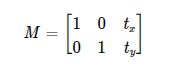

In [19]:
M = np.float32([[1,0,100],[0,1,50]])
dst = cv.warpAffine(img,M,(width,height))
cv.imshow('img',dst)
cv.waitKey(0)
cv.destroyAllWindows()

Rotation

In [24]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg',cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols = img.shape

M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows - 1)/2.0),60,1)
dst = cv.warpAffine(img,M,(cols,rows))
cv.imshow('img',dst)
cv.waitKey(0)
cv.destroyAllWindows()

Affine Transformation

In affine transformation, all parallel lines in the original image will still be parallel in the output image. To find the transformation matrix, we need three points from the input image and their corresponding locations in the output image. Then cv.getAffineTransform will create a 2x3 matrix which is to be passed to cv.warpAffine.

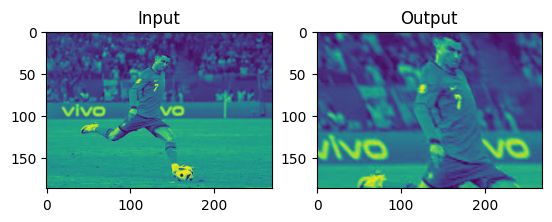

In [25]:
import matplotlib.pyplot as plt
pts1 = np.float32([[50,50],[100,50],[50,100]])
pts2 = np.float32([[10,50],[100,50],[50,150]])

M = cv.getAffineTransform(pts1,pts2)

dst = cv.warpAffine(img,M,(cols,rows))

plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

Perspective Transformation

For perspective transformation, you need a 3x3 transformation matrix. Straight lines will remain straight even after the transformation. To find this transformation matrix, you need 4 points on the input image and corresponding points on the output image. Among these 4 points, 3 of them should not be collinear. Then the transformation matrix can be found by the function cv.getPerspectiveTransform. Then apply cv.warpPerspective with this 3x3 transformation matrix.

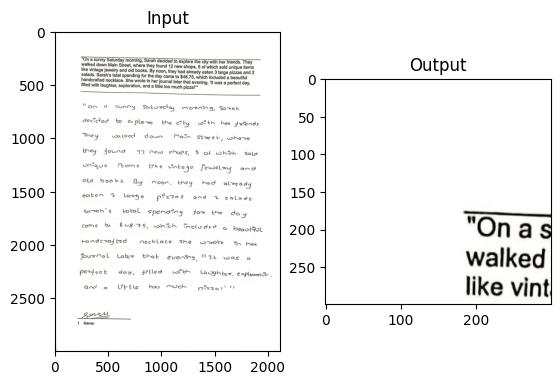

In [26]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/try_image.jpg')
assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols,ch = img.shape
 
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
 
M = cv.getPerspectiveTransform(pts1,pts2)
 
dst = cv.warpPerspective(img,M,(300,300))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

Image Thresholding

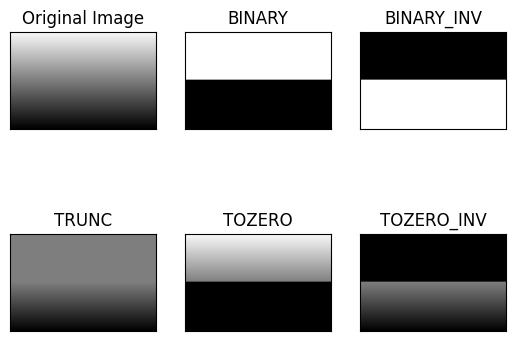

In [27]:
## Simple Thresholding
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/gradient.png',cv.IMREAD_GRAYSCALE)

ret,thresh1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,127,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,127,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,127,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
 
plt.show()

##### Adaptive Thresholding
an image has different lighting conditions in different areas. In that case, adaptive thresholding can help. Here, the algorithm determines the threshold for a pixel based on a small region around it. So we get different thresholds for different regions of the same image which gives better results for images with varying illumination.

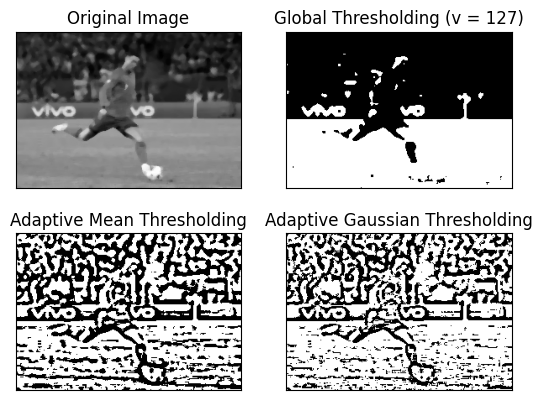

In [36]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg',cv.IMREAD_GRAYSCALE)

img = cv.medianBlur(img,5)
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,2)

titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']

images = [img,th1,th2,th3]
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

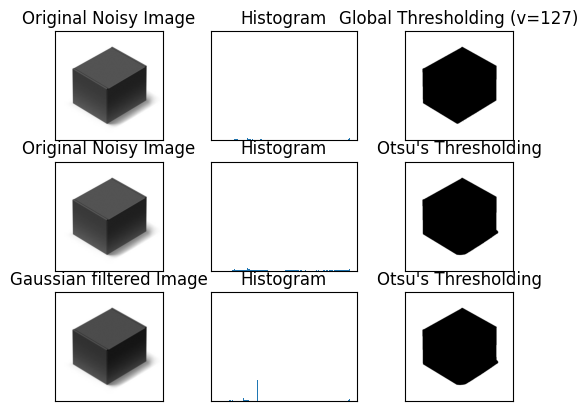

In [40]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/black_white.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 

# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
 
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
 
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()


In [41]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg',cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
blur = cv.GaussianBlur(img,(5,5),0)

# find normalized_histogram, and its cumulative distribution function
hist = cv.calcHist([blur],[0],None,[256],[0,256])
hist_norm = hist.ravel()/hist.sum()
Q = hist_norm.cumsum()

bins = np.arange(256)

fn_min = np.inf
thresh = -1

for i in range(1,256):
    p1,p2 = np.hsplit(hist_norm,[i]) # probabilities
    q1,q2 = Q[i],Q[255]-Q[i] # cum sum of classes
    if q1 < 1.e-6 or q2 < 1.e-6:
        continue
    b1,b2 = np.hsplit(bins,[i]) # weights

    # finding means and variances
    m1,m2 = np.sum(p1*b1)/q1, np.sum(p2*b2)/q2
    v1,v2 = np.sum(((b1-m1)**2)*p1)/q1,np.sum(((b2-m2)**2)*p2)/q2

    # calculates the minimization function
    fn = v1*q1 + v2*q2
    if fn < fn_min:
        fn_min = fn
        thresh = i

# find otsu's threshold value with OpenCV function
ret, otsu = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
print( "{} {}".format(thresh,ret) )

98 97.0


In [42]:
cv.imshow('Original', img)
cv.imshow('Blurred', blur)
cv.imshow('Otsu Threshold', otsu)
cv.waitKey(0)
cv.destroyAllWindows()

Image Smoothing

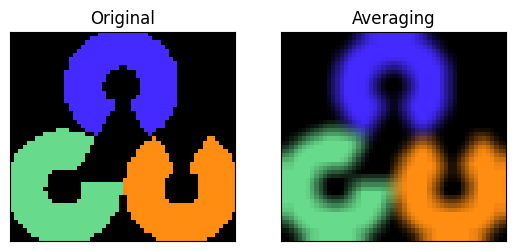

In [43]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/opencv-logo-small.png')
kernel = np.ones((5,5),np.float32)/25
dst = cv.filter2D(img,-1,kernel)

plt.subplot(1,2,1),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

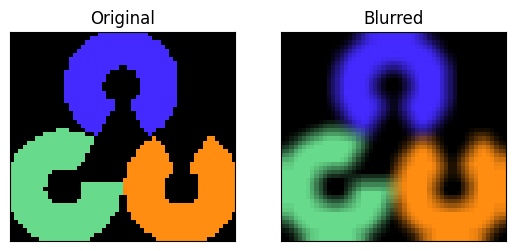

In [44]:
blur = cv.blur(img,(5,5))
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

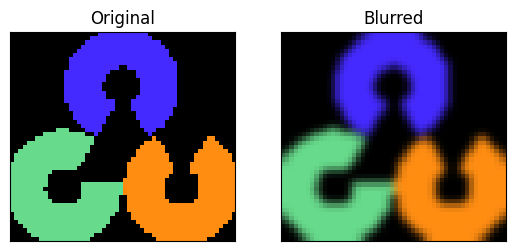

In [46]:
blur = cv.GaussianBlur(img,(5,5),0)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

#### Median Blurring
cv.medianBlur() takes the median of all the pixels under the kernel area and the central element is replaced with this median value. This is highly effective against salt-and-pepper noise in an image. Interestingly, in the above filters, the central element is a newly calculated value which may be a pixel value in the image or a new value. But in median blurring, the central element is always replaced by some pixel value in the image.

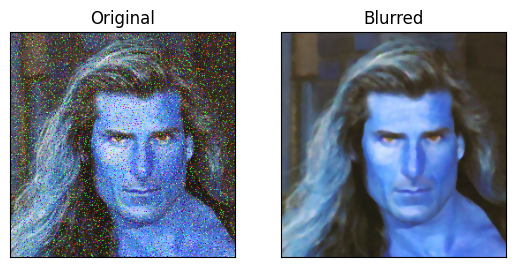

In [48]:
img = cv.imread('salt_and_pepper.png')
median = cv.medianBlur(img,5)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(median),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

Bilateral filter looks at:

How far a neighboring pixel is (spatial distance)

How different it is in color/intensity (range difference)

Then it gives:

High weight to nearby similar pixels

Low weight to pixels that are different

That way, it does not average across edges!

So the 255 stays unblurred while noise in flat regions is smoothed.

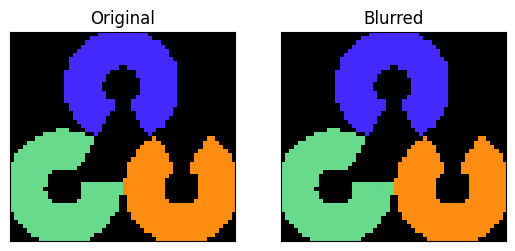

In [50]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/opencv-logo-small.png')
blur = cv.bilateralFilter(img,9,75,75)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

Morphological Transformation

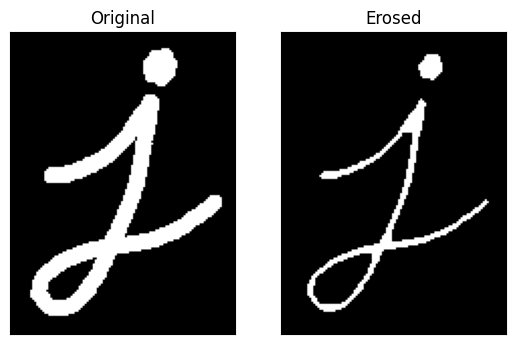

In [52]:
img = cv.imread('j.png')
kernel = np.ones((5,5),np.uint8)
erosion = cv.erode(img,kernel,iterations=1)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(erosion),plt.title('Erosed')
plt.xticks([]), plt.yticks([])
plt.show()

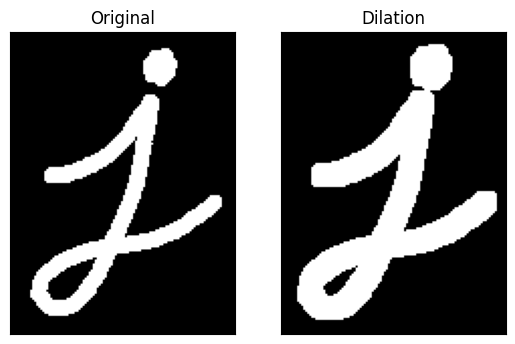

In [53]:
## Dilation
dilation = cv.dilate(img,kernel,iterations=1)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dilation),plt.title('Dilation')
plt.xticks([]), plt.yticks([])
plt.show()

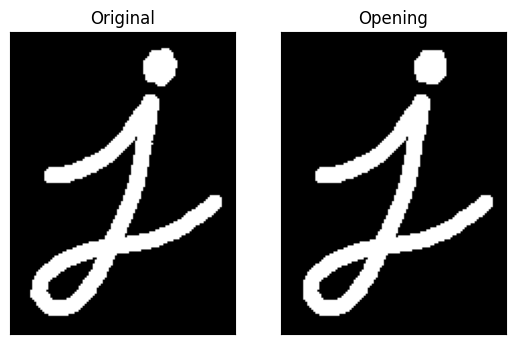

In [54]:
opening = cv.morphologyEx(img,cv.MORPH_OPEN,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(opening),plt.title('Opening')
plt.xticks([]), plt.yticks([])
plt.show()

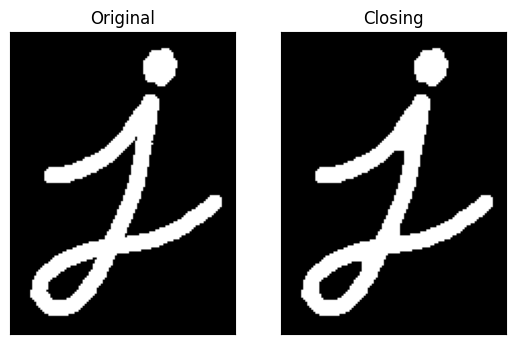

In [55]:
closing = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(closing),plt.title('Closing')
plt.xticks([]), plt.yticks([])
plt.show()

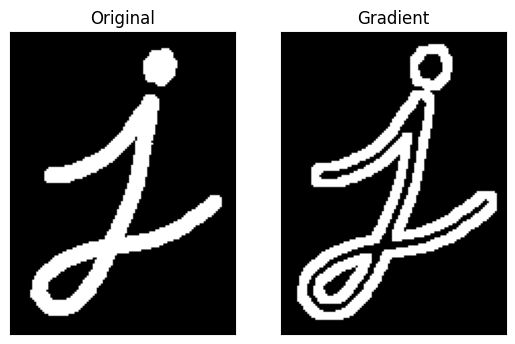

In [56]:
gradient = cv.morphologyEx(img, cv.MORPH_GRADIENT, kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(gradient),plt.title('Gradient')
plt.xticks([]), plt.yticks([])
plt.show()

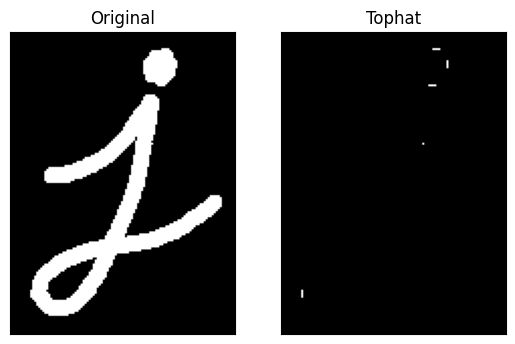

In [57]:
tophat = cv.morphologyEx(img, cv.MORPH_TOPHAT, kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(tophat),plt.title('Tophat')
plt.xticks([]), plt.yticks([])
plt.show()

In [58]:
## For different structuring element
cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))

array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

#### Image Gradients

(Text(0.5, 1.0, 'Sobel Y'), ([], []), ([], []))

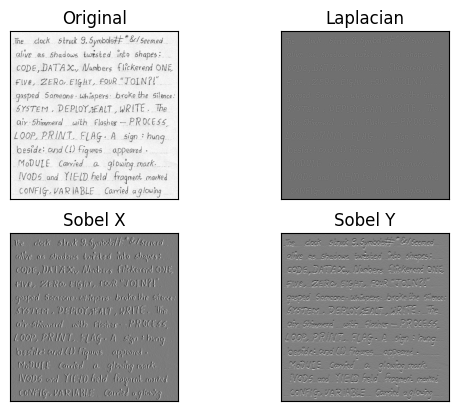

In [61]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/writing.png',cv.IMREAD_GRAYSCALE)

laplacian = cv.Laplacian(img,cv.CV_64F)
sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=5)
sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=5)
 
plt.subplot(2,2,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,2),plt.imshow(laplacian,cmap = 'gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])

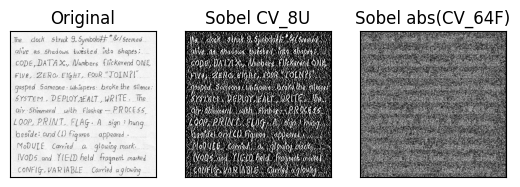

In [62]:
# Output dtype = cv.CV_8U
sobelx8u = cv.Sobel(img,cv.CV_8U,1,0,ksize=5)
 
# Output dtype = cv.CV_64F. Then take its absolute and convert to cv.CV_8U
sobelx64f = cv.Sobel(img,cv.CV_64F,1,0,ksize=5)
abs_sobel64f = np.absolute(sobelx64f)
sobel_8u = np.uint8(abs_sobel64f)
 
plt.subplot(1,3,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(sobelx8u,cmap = 'gray')
plt.title('Sobel CV_8U'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(sobel_8u,cmap = 'gray')
plt.title('Sobel abs(CV_64F)'), plt.xticks([]), plt.yticks([])
 
plt.show()

#### Canny Edge Detection

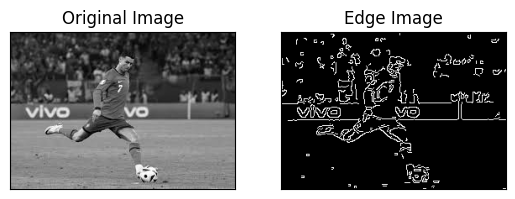

In [69]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg',cv.IMREAD_GRAYSCALE)
edges = cv.Canny(img,170,255)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
 
plt.show()

In [70]:
def nothing(x):
    pass

img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray,(5,5),1.0)

cv.namedWindow('Canny Edge Detection')

# Trackbars for threshold adjustment
cv.createTrackbar('Min Threshold','Canny Edge Detection',50,255,nothing)
cv.createTrackbar('Max Threshold','Canny Edge Detection',120,255,nothing)

while True:
    min_val = cv.getTrackbarPos('Min Threshold','Canny Edge Detection')
    max_val = cv.getTrackbarPos('Max Threshold','Canny Edge Detection')

    edges = cv.Canny(blur,min_val,max_val)

    cv.imshow('Canny Edge Detection',edges)

    if cv.waitKey(1) & 0xFF == 27:
        break

cv.destroyAllWindows()



#### Image Pyramids

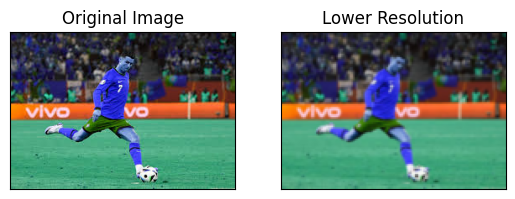

In [74]:
higher_reso = img

# Reduce resolution using Gaussian pyramid
lower_reso = cv.pyrDown(higher_reso)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(lower_reso,cmap = 'gray')
plt.title('Lower Resolution'), plt.xticks([]), plt.yticks([])
 
plt.show()

In [75]:
img = cv.imread('test.png')
imgray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret,thresh = cv.threshold(imgray,127,255,0)
contours,hierarchy = cv.findContours(thresh,cv.RETR_TREE,cv.CHAIN_APPROX_SIMPLE)

In [76]:
cv.drawContours(img,contours,-1,(0,255),3)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]

In [77]:
cv.imshow('Contours', img)
cv.waitKey(0)
cv.destroyAllWindows()

In [79]:
cnt = contours[0]
x,y,w,h = cv.boundingRect(cnt)
cv.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]

In [80]:
cv.imshow('Contours', img)
cv.waitKey(0)
cv.destroyAllWindows()

In [83]:
(x,y),radius = cv.minEnclosingCircle(cnt)
center = (int(x),int(y))
radius = int(radius)
cv.circle(img,center,radius,(0,255,0),2)
cv.imshow('Contours', img)
cv.waitKey(0)
cv.destroyAllWindows()

Histogram

In [84]:
img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg',cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([img],[0],None,[256],[0,255])
cv.circle(img,center,radius,(0,255,0),2)
cv.imshow('Histogram', hist)
cv.waitKey(0)
cv.destroyAllWindows()

In [85]:
hist,bins = np.histogram(img.ravel(),256,[0,256])

/tmp/ipykernel_6667/724745362.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256]); plt.show()


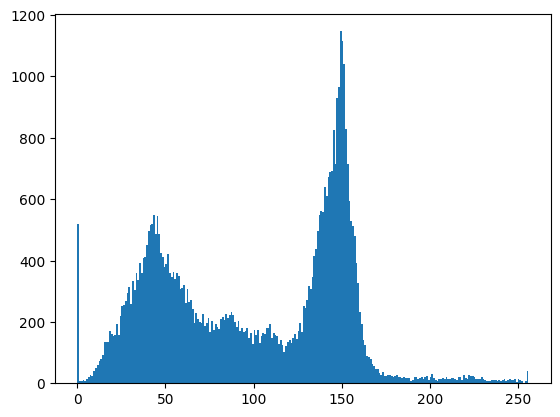

In [86]:
plt.hist(img.ravel(),256,[0,256]); plt.show()

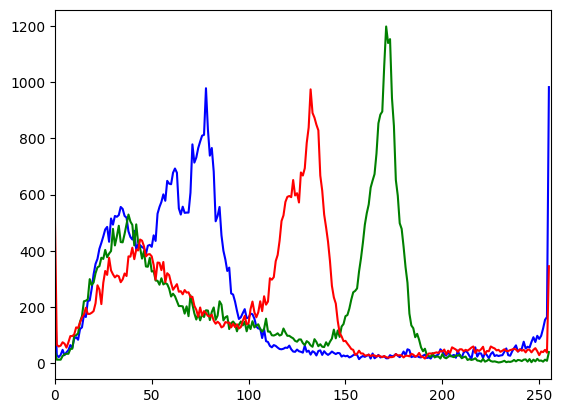

In [88]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Processing-with-OpenCV/images.jpeg')

color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()